In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.manifold import TSNE
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, CustomJS, ColumnDataSource, Slider
from bokeh.layouts import column
from bokeh.palettes import all_palettes
output_notebook()

In [ ]:
pip install pdfminer.six

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 32.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTTextContainer

In [ ]:
dataset=[]
record=[]
name=""

In [ ]:
for i in range (1,21):
    print(i)
    text1=""
    name="pdf"+ str(i)+".pdf"
    for page_layout in extract_pages(name):
        for element in page_layout:
            if isinstance(element, LTTextContainer):
                #print(element.get_text())
                text1=text1+element.get_text()+"\n"
    record.append(text1)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [ ]:
import pandas as pd

# Define a dictionary containing data
data = {'Name': ["paper 1", "paper 2", " paper 3 ", "paper 4","paper 5","paper 6","paper 7","paper 8","paper 9","paper 10","paper 11","paper 12","paper 13","paper 14","paper 15","paper 16","paper 17","paper 18","paper 19","paper 20"] }
# Convert the dictionary into DataFrame
df = pd.DataFrame(data)

In [ ]:
df["content"] = record

In [ ]:
df.info()
df.to_csv('pdfcontent.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     20 non-null     object
 1   content  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [ ]:
import pandas as pd
df=pd.read_csv('pdfcontent.csv')

In [ ]:
import string
from nltk.corpus import stopwords
import re
from nltk.tokenize import RegexpTokenizer

In [ ]:

df['content'] = df['content'].apply(lambda x: re.sub("-\n",'',x))
df['content'] = df['content'].apply(lambda x: re.sub("\n",' ',x))

In [ ]:
#defining the function to remove punctuation

def remove_punctuation(text):
    text=text.replace("/n"," ")
    tokenizer = RegexpTokenizer(r"\w+")
    punctuationfree = tokenizer.tokenize(text)
    punctuationfree=" ".join([i for i in punctuationfree if i not in string.punctuation])
    return punctuationfree
#storing the puntuation free text
df['content']= df['content'].apply(lambda x:remove_punctuation(x))

In [ ]:
df['content']= df['content'].apply(lambda x: x.lower())

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:

lemmatizer = WordNetLemmatizer()
#A function which takes a sentence/corpus and gets its lemmatized version.
def lemmatizeSentence(sentence):
    token_words=word_tokenize(sentence)
#we need to tokenize the sentence or else lemmatizing will return the entire sentence as is.
    lemma_sentence=[]
    for word in token_words:
        lemma_sentence.append(lemmatizer.lemmatize(word))
        lemma_sentence.append(" ")
    return "".join(map(str,lemma_sentence))

In [ ]:
import nltk
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
nltk.download('punkt_tab')
nltk.download('wordnet')
df["content"] = df["content"].apply(lambda text: lemmatizeSentence(text))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

In [ ]:
import re
df['content'] = df['content'].apply(lambda x: re.sub("\d",' ',x))
df['content'] = df['content'].apply(lambda x: re.sub("_",' ',x))
df['content'] = df['content'].apply(lambda x:' '.join( [w for w in x.split() if len(w)>2]))

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:

d=Counter(" ".join(df["content"]).split()).most_common(5)
f=dict(d)

<BarContainer object of 5 artists>

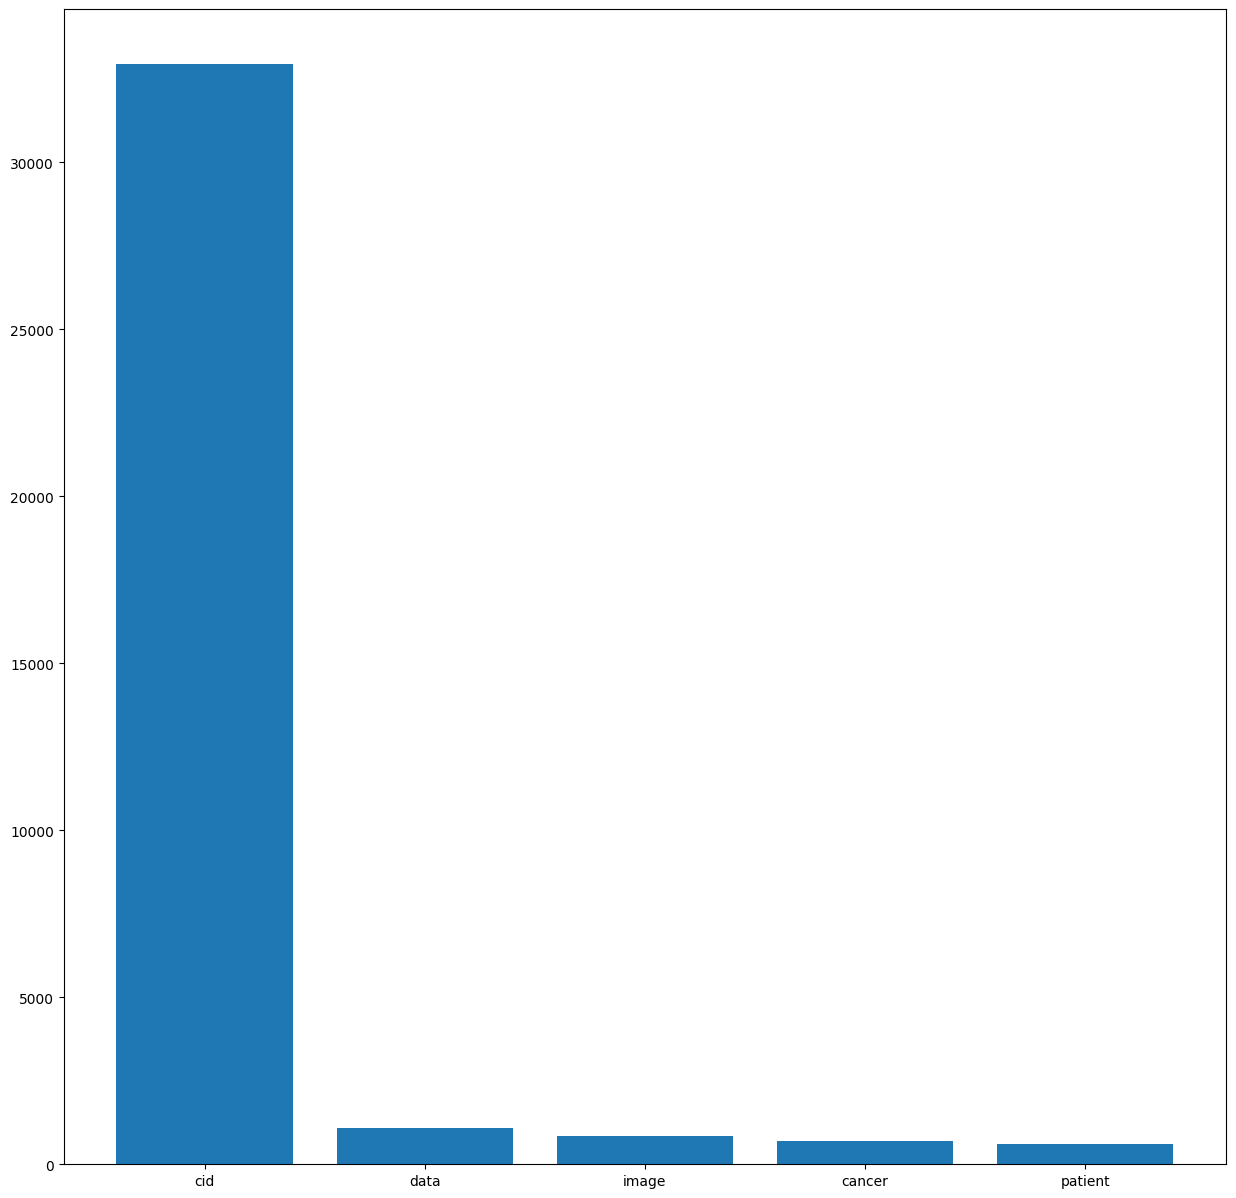

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(15,15))
plt.bar(range(len(f)), values, tick_label=names)

In [ ]:
pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

In [ ]:
from keybert import KeyBERT

In [ ]:
from sentence_transformers import SentenceTransformer
import torch

# Ensure model is loaded on GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load the transformer model directly with GPU support
sentence_model = SentenceTransformer('all-mpnet-base-v2', device=device)
kw_model = KeyBERT(model=sentence_model)

Using device: cpu


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
df['content_new']=df['content']

In [ ]:
for i in range(0,20):
    keywords = kw_model.extract_keywords(df['content'][i],keyphrase_ngram_range=(1, 3),highlight=False, top_n=70)
    keywords_list= list(dict(keywords).keys())
    s=""
    for kw in keywords_list:
        # print(kw)
        s=s+" "+kw
    df['content_new'][i]=s

In [ ]:
d=Counter(" ".join(df["content_new"]).split()).most_common(5)
f=dict(d)
f

{'leukemia': 163,
 'cancer': 157,
 'detection': 136,
 'healthcare': 123,
 'melanoma': 103}

<BarContainer object of 5 artists>

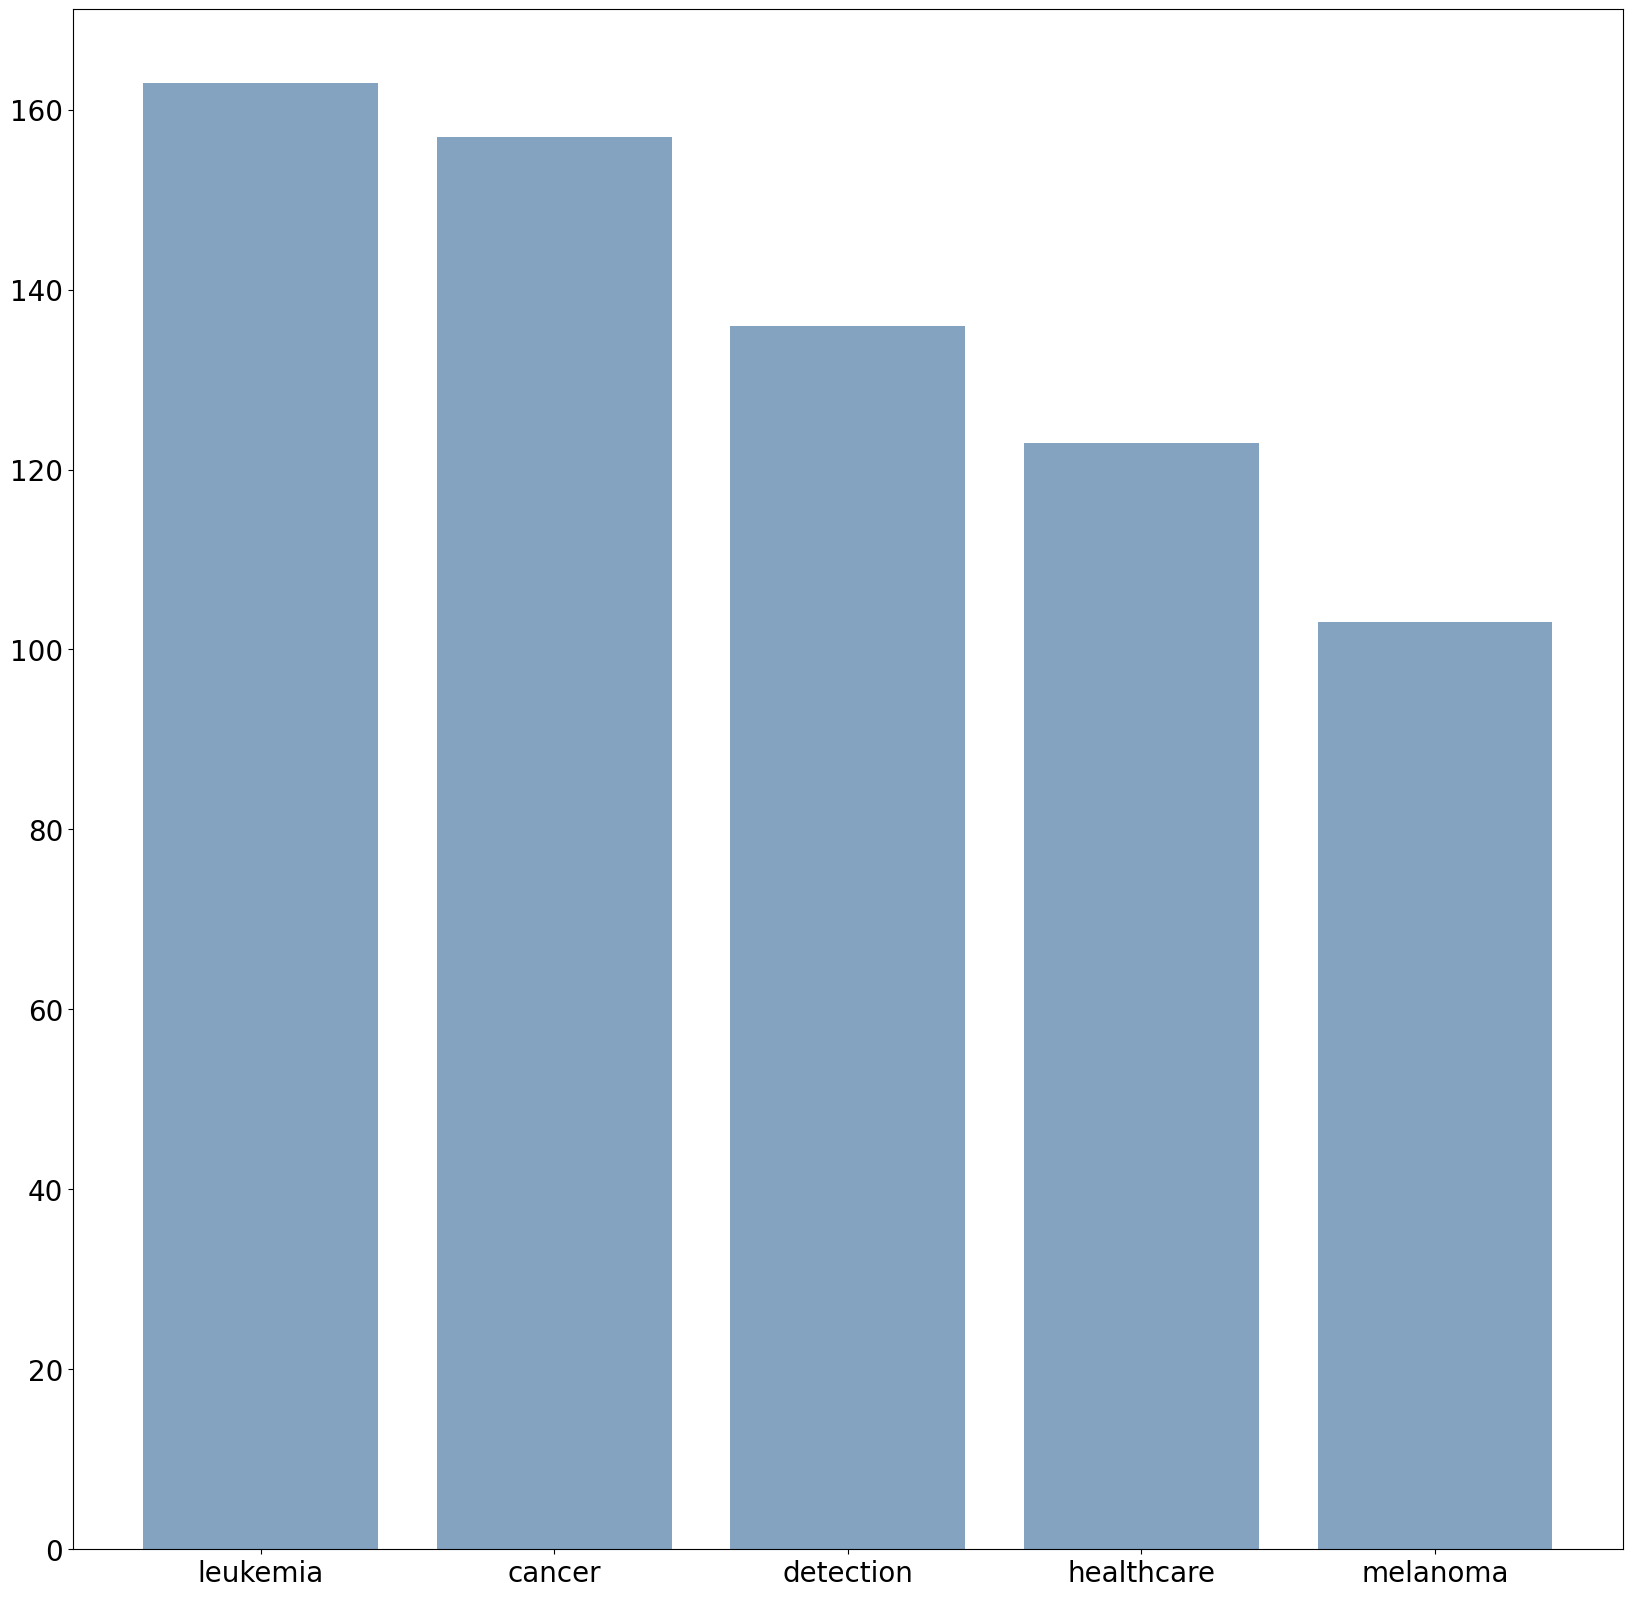

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(20,20))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.bar(range(len(f)), values, tick_label=names,color=(0.2, 0.4, 0.6, 0.6))

In [ ]:
df

,Unnamed: 0,Name,content,content_new
0,0,paper 1,received august accepted september date public...,mri scan encryption deep learning medical hea...
1,1,paper 2,ieee transaction neural network learning syste...,neural network medical convolutional network ...
2,2,paper 3,ieee international conference communication ic...,computing telesurgery 𝜃𝑐𝑎𝑛𝑐𝑒𝑟 diagnosis healt...
3,3,paper 4,content list available sciencedirect journal i...,integrating medical data data integration med...
4,4,paper 5,international conference automation control me...,classifier classify tumor cancer detection cl...
5,5,paper 6,bullet jurnal multidisiplin ilmu volume august...,intelligence healthcare petroleum artificial ...
6,6,paper 7,iqbal cancer cell int http doi org cancer cell...,artificial intelligence medical artificial in...
7,7,paper 8,received january revised september accepted oc...,healthcare digital twin healthcare digital he...
8,8,paper 9,review began review ended published copyright ...,machine learning melanoma artificial intellig...
9,9,paper 10,article artiﬁcial intelligence applied first s...,algorithm naevoid melanoma dermatopathology m...


In [ ]:
df.to_csv('bertoncology.csv')

In [ ]:
import pandas as pd
df=pd.read_csv('bertoncology.csv')

In [ ]:
x_train=df['content_new'].to_numpy()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tf_idf_vectorizer=TfidfVectorizer(min_df=0.07)

cv_vectorizer= CountVectorizer()

In [ ]:
tf_idf_arr= tf_idf_vectorizer.fit_transform(x_train)

# cv_arr=cv_vectorizer.fit_transform(x_train)

In [ ]:
import numpy as np

In [ ]:
tf_idf_arr

<20x187 sparse matrix of type '<class 'numpy.float64'>'
	with 706 stored elements in Compressed Sparse Row format>

In [ ]:
# vocab_cv_arr=cv_vectorizer.get_feature_names()

In [ ]:
vocab_tf_idf = tf_idf_vectorizer.get_feature_names_out()

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model= LatentDirichletAllocation(n_components=4, max_iter = 200, random_state=20)

X_topics= lda_model.fit_transform(tf_idf_arr)

topic_words=lda_model.components_

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model= LatentDirichletAllocation(n_components=5, max_iter = 100, random_state=20)

X_topics= lda_model.fit_transform(cv_arr)

topic_words=lda_model.components_

In [ ]:
# Log Likelyhood: Higher the better
print("Log Likelihood: ", lda_model.score(tf_idf_arr))

# Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
print("Perplexity: ", lda_model.perplexity(tf_idf_arr))

# See model parameters
print(lda_model.get_params())


Log Likelihood:  -468.73811714437363
Perplexity:  1156.9365830244672
{'batch_size': 128, 'doc_topic_prior': None, 'evaluate_every': -1, 'learning_decay': 0.7, 'learning_method': 'batch', 'learning_offset': 10.0, 'max_doc_update_iter': 100, 'max_iter': 200, 'mean_change_tol': 0.001, 'n_components': 4, 'n_jobs': None, 'perp_tol': 0.1, 'random_state': 20, 'topic_word_prior': None, 'total_samples': 1000000.0, 'verbose': 0}


In [ ]:
import numpy as np

In [ ]:
topic_number =[]
word=[]

In [ ]:
n_top_words=5

# for i, topic_dist in enumerate(topic_words):

#     sorted_topic_dist = np.argsort(topic_dist)
#     topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]

#     topic_words= topic_words[:-n_top_words:-1]
#     print("topic", str(i+1), topic_words)
#     topic_number.append("topic"+str(i+1))
#     word.append(topic_words)
#     print(" ")

In [ ]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# Preprocessing: Tokenize and clean your text data (if not already done)
documents = [doc.split() for doc in df['content']]  # Replace with actual tokenized text data

# Create a Gensim dictionary and corpus
dictionary = Dictionary(documents)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Store topics' words and calculate coherence
topic_coherence_scores = []

# Iterate over each topic
for i, topic_dist in enumerate(topic_words):

    sorted_topic_dist = np.argsort(topic_dist)
    topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]
    topic_words = topic_words[:-n_top_words:-1]
    print("Topic", str(i+1), topic_words)
    topic_number.append("Topic" + str(i+1))
    word.append(topic_words)

    # Calculate coherence score for each topic using gensim's CoherenceModel
    gensim_lda_topic = [dictionary[word_id] for word_id in sorted_topic_dist[-n_top_words:]]

    coherence_model = CoherenceModel(
        topics=[gensim_lda_topic],
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'  # You can choose 'c_v', 'u_mass', or 'c_npmi'
    )

    coherence_score = coherence_model.get_coherence()
    topic_coherence_scores.append(coherence_score)
    print(f"Coherence score for Topic {i+1}: {coherence_score:.4f}")

    print(" ")

# Display all topics' coherence scores
print("\nTopic Coherence Scores:")
for idx, score in enumerate(topic_coherence_scores):
    print(f"Topic {idx+1}: {score:.4f}")


Topic 1 ['melanoma' 'lung' 'tumor' 'detection']
Coherence score for Topic 1: 0.2988
 
Topic 2 ['deep' 'cancer' 'image' 'research']
Coherence score for Topic 2: 0.3112
 
Topic 3 ['healthcare' 'patient' 'medical' 'cancer']
Coherence score for Topic 3: 0.3757
 
Topic 4 ['leukemia' 'melanoma' 'detection' 'revolution']
Coherence score for Topic 4: 0.1317
 

Topic Coherence Scores:
Topic 1: 0.2988
Topic 2: 0.3112
Topic 3: 0.3757
Topic 4: 0.1317


In [ ]:
topic_df=pd.DataFrame(topic_number)
topic_df["topic words"]=word

In [ ]:
print(topic_df.to_string())

        0                                  topic words
0  Topic1           [melanoma, lung, tumor, detection]
1  Topic2              [deep, cancer, image, research]
2  Topic3       [healthcare, patient, medical, cancer]
3  Topic4  [leukemia, melanoma, detection, revolution]


In [ ]:
doc_name=[]
doc_top=[]

In [ ]:
doc_topic=lda_model.transform(tf_idf_arr)

for n in range(doc_topic.shape[0]):

    topic_doc=doc_topic[n].argmax()

    print("document", n+1, " - - Topic: ", topic_doc+1)
    doc_name.append(n+1)
    doc_top.append(topic_doc+1)

document 1  - - Topic:  3
document 2  - - Topic:  2
document 3  - - Topic:  3
document 4  - - Topic:  3
document 5  - - Topic:  1
document 6  - - Topic:  3
document 7  - - Topic:  3
document 8  - - Topic:  3
document 9  - - Topic:  1
document 10  - - Topic:  4
document 11  - - Topic:  2
document 12  - - Topic:  2
document 13  - - Topic:  4
document 14  - - Topic:  3
document 15  - - Topic:  3
document 16  - - Topic:  4
document 17  - - Topic:  3
document 18  - - Topic:  3
document 19  - - Topic:  4
document 20  - - Topic:  4


In [ ]:
doc=pd.DataFrame(doc_name)
doc["topic"]=doc_top

In [ ]:
doc

,0,topic
0,1,3
1,2,2
2,3,3
3,4,3
4,5,1
5,6,3
6,7,3
7,8,3
8,9,1
9,10,4


<Axes: xlabel='topic', ylabel='count'>

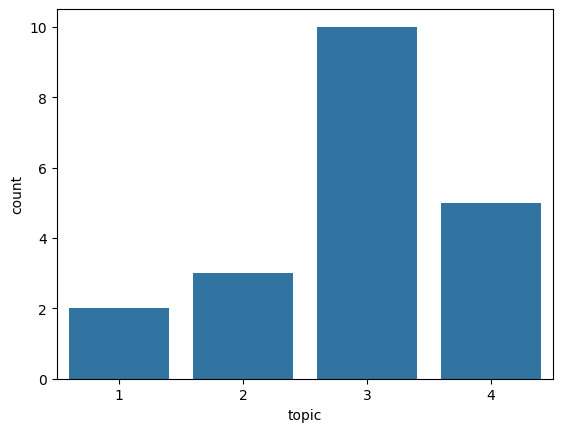

In [ ]:
import seaborn as sns
sns.countplot(x ='topic', data = doc)

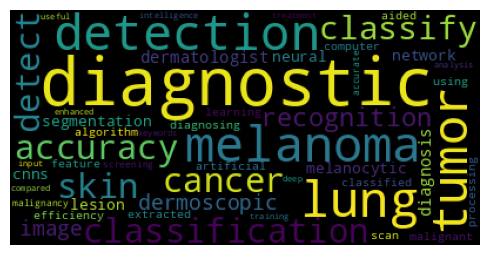

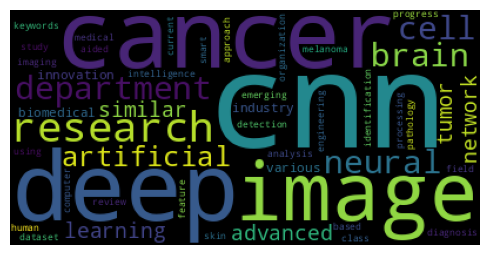

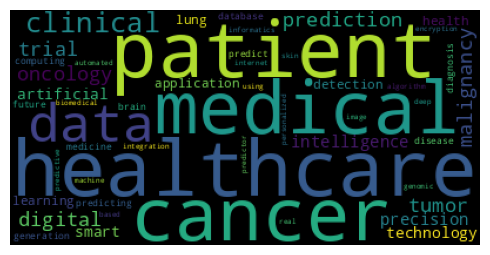

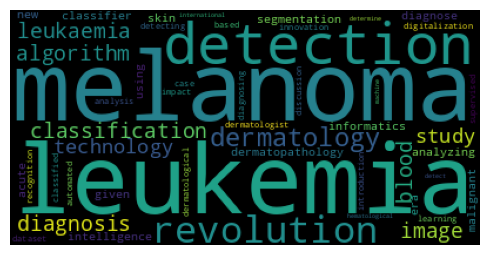

IndexError: index 4 is out of bounds for axis 0 with size 4

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Generate a word cloud image for given topic
def draw_word_cloud(index):
  imp_words_topic=""
  comp=lda_model.components_[index]
  vocab_comp = zip(vocab_tf_idf, comp)
  sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:50]
  for word in sorted_words:
    imp_words_topic=imp_words_topic+" "+word[0]

  wordcloud = WordCloud().generate(imp_words_topic)
  plt.figure( figsize=(5,5))
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout()
  plt.show()
# topic 0
draw_word_cloud(0)
draw_word_cloud(1)
draw_word_cloud(2)
draw_word_cloud(3)